In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
"""
Hard Voting: The final prediction is the class that receives the most votes from all models.
Soft Voting: The final prediction is based on the average (or weighted average) of the predicted probabilities, and the class with the highest average probability is selected.
"""

In [13]:
data=pd.read_csv("Iris.csv")

In [15]:
data.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [18]:
df = data.drop(columns=['Id'])

In [19]:
df

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


In [23]:
df.value_counts(df['Species'])

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

In [24]:
df.isnull().sum()

SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

In [25]:
df.duplicated().sum()

np.int64(3)

In [26]:
df=df.drop_duplicates()

In [27]:
df.shape

(147, 5)

In [28]:
from sklearn.preprocessing import LabelEncoder

encoder=LabelEncoder()

df['Species']=encoder.fit_transform(df['Species'])

In [29]:
df

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


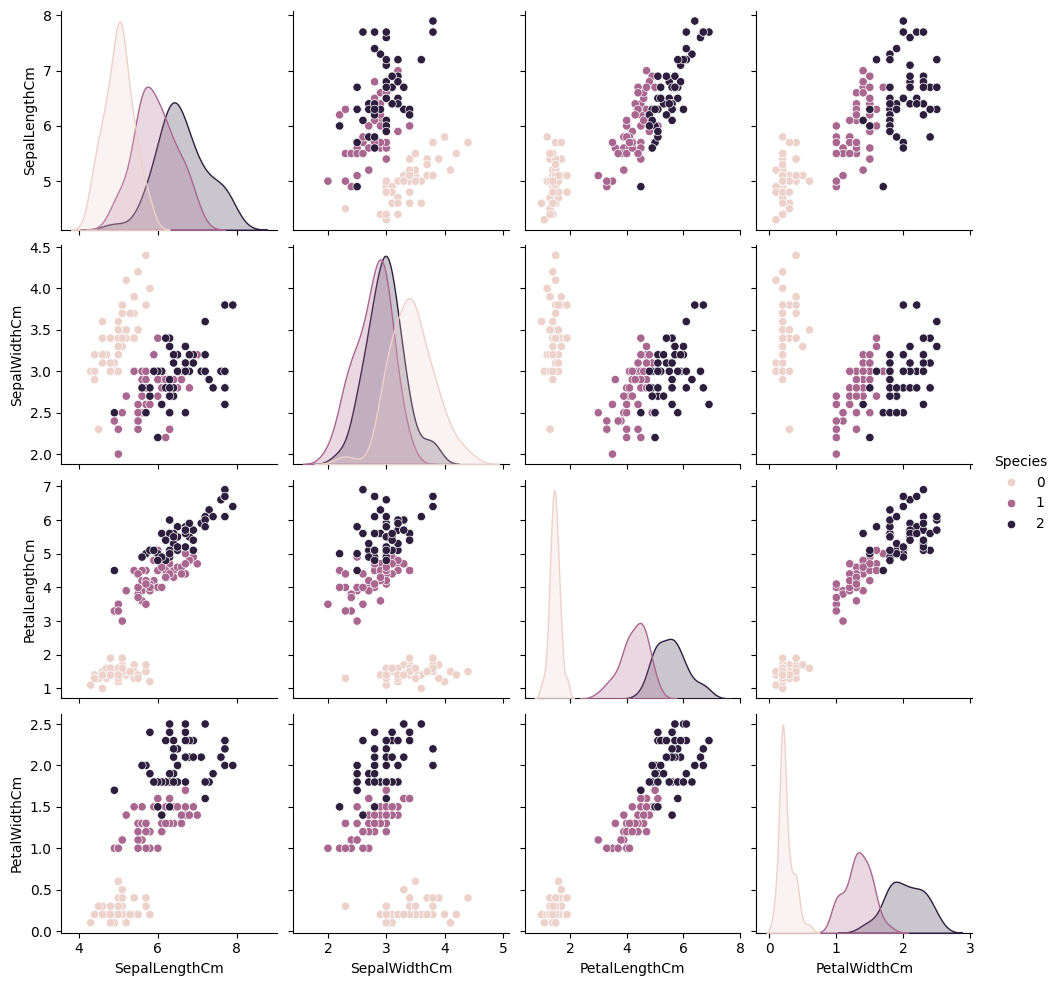

In [32]:
import seaborn as sns

sns.pairplot(df,hue='Species')

In [34]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

In [35]:
m1=LogisticRegression()
m2=KNeighborsClassifier()
m3=RandomForestClassifier()

In [37]:
from sklearn.ensemble import VotingClassifier

In [36]:
estimators=[('lr',m1),('knn',m2),('rf',m3)]

In [44]:
x=df.iloc[0:,0:3]

In [46]:
y=df.iloc[:,4]

In [49]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=42,test_size=0.2)



In [58]:

for name, estimator in estimators:
    z = cross_val_score(estimator=estimator, X=x, y=y, cv=10, scoring='accuracy')
    print(name, np.round(np.mean(z), 2))
    


lr 0.96
knn 0.94
rf 0.94


In [60]:
vc=VotingClassifier(estimators=estimator)
z = cross_val_score(estimator=estimator, X=x, y=y, cv=10, scoring='accuracy')
print(np.round(np.mean(z), 2))

0.95


In [61]:
vc=VotingClassifier(estimators=estimator,voting='soft')
z = cross_val_score(estimator=estimator, X=x, y=y, cv=10, scoring='accuracy')
print(np.round(np.mean(z), 2))

0.94
